# Phase 2 - 05: GRPO 训练（0.8B 模型 + JSON 格式输出）

## 本节目标

用 TRL 的 `GRPOTrainer` 对 **Qwen3.5-0.8B** 做强化学习微调，让模型学会：
1. 解题时输出严格的 JSON 格式：`{"steps": [...], "answer": 数字}`
2. 推理步骤正确（steps 有意义）
3. 最终答案与 GSM8K 标准答案一致

## 为什么换成这个任务？

03/04 实验的根本问题是任务太简单——Qwen3.5-2B 未训练就能完成。

本节的改进：
- **换更弱的模型**：0.8B 参数量不到 2B 的一半，能力明显更弱
- **换更难的任务**：严格 JSON 格式输出，0.8B baseline 正确率约 25%，有真实的学习空间
- **reward 更纯粹**：JSON 可解析（格式分）+ answer 正确（结果分），完全自动验证

探测实验（05 之前）发现 0.8B 的典型失败模式：
1. 算错（48 - 15 + 30 算成 73）
2. JSON 格式错误（steps 里混入 `1.` `2.` 编号导致解析失败）
3. 生成被截断，answer 字段缺失

## GRPO 简介

GRPO（Group Relative Policy Optimization）是 DeepSeek-R1 用的算法，比 PPO 简单：
- 同一道题生成 G 个回答（一个「组」）
- 组内做相对比较，reward 高于均值的回答得到正梯度，低于均值的得到负梯度
- 不需要单独训练 Critic 网络，省显存

```
advantage_i = (reward_i - mean(rewards)) / std(rewards)
```

## 1. 导入依赖 & 复用工具函数（从 01/02 搬来）

In [7]:
# 1-1 导入依赖 & 工具函数
import re
import math
import json
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from trl import GRPOConfig, GRPOTrainer
from datasets import Dataset

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
MODEL_ID = os.path.expanduser("~/.cache/modelscope/hub/models/Qwen/Qwen3___5-0___8B")

print(f"torch:   {torch.__version__}")
print(f"device:  {DEVICE}")

# ── 答案归一化 ────────────────────────────────────────────────────────────────
def normalize_answer(s) -> str:
    if s is None:
        return ""
    s = re.sub(r"[,，]", "", str(s).strip())
    s = re.sub(r"[^0-9\.\-]", "", s)
    try:
        f = float(s)
        return str(int(f)) if f == int(f) else str(f)
    except:
        return s

# ── 解析输出（JSON）────────────────────────────────────────────────────────────
def parse_output(text: str) -> dict:
    """
    从模型输出中提取 JSON，返回 {"steps": [...], "answer": 数字}。
    容错处理：尝试从输出中找到第一个合法 JSON 对象。
    """
    result = {"steps": None, "answer": None, "raw_json": None}
    # 先去掉 markdown 代码块
    text = re.sub(r"```json\s*", "", text)
    text = re.sub(r"```\s*", "", text)
    try:
        m = re.search(r"\{.*\}", text, re.DOTALL)
        if m:
            obj = json.loads(m.group())
            result["raw_json"] = obj
            result["steps"] = obj.get("steps")
            result["answer"] = obj.get("answer")
    except:
        pass
    return result

print("工具函数加载完成")

torch:   2.10.0
device:  mps
工具函数加载完成


## 2. Reward 函数

只优化格式，不管答案对不对：

| 条件 | 得分 |
|---|---|
| 输出可被 `json.loads` 解析 | +0.5 |
| 含 `steps` 字段且为 list | +0.3 |
| 含 `answer` 字段且为数字 | +0.2 |

**设计理由**：
- baseline 格式正确率 63%，组内几乎所有题都有对有错，梯度信号稳定
- 不依赖答案正确性，所有题都能参与训练，数据利用率高
- 目标清晰：训练完只看格式正确率从 63% 涨到多少

In [8]:
# 2-1 Reward 函数
def compute_reward(output: str, correct_answer: str = None) -> dict:
    """
    只评估格式，不评估答案正确性。
    - JSON 可解析：+0.5
    - steps 是 list：+0.3
    - answer 是数字：+0.2
    """
    parsed = parse_output(output)
    score = 0.0

    if parsed["raw_json"] is None:
        return {"json": 0.0, "steps": 0.0, "answer_field": 0.0, "total": 0.0}

    score += 0.5  # JSON 可解析

    steps_score = 0.0
    if isinstance(parsed["steps"], list):
        steps_score = 0.3
        score += steps_score

    answer_score = 0.0
    if parsed["answer"] is not None:
        try:
            float(parsed["answer"])
            answer_score = 0.2
            score += answer_score
        except:
            pass

    return {
        "json":         0.5,
        "steps":        steps_score,
        "answer_field": answer_score,
        "total":        round(score, 2),
    }


def _completion_to_str(completion) -> str:
    if isinstance(completion, str):
        return completion
    if isinstance(completion, list):
        for msg in reversed(completion):
            if isinstance(msg, dict) and msg.get("role") == "assistant":
                return msg.get("content", "")
        return " ".join(msg.get("content", "") for msg in completion if isinstance(msg, dict))
    return str(completion)


def reward_fn(completions: list, **kwargs) -> list[float]:
    texts = [_completion_to_str(c) for c in completions]
    return [compute_reward(t)["total"] for t in texts]


# 快速验证
r1 = compute_reward('{"steps": ["48 - 15 = 33", "33 + 30 = 63"], "answer": 63}')
print("完美格式:", r1)

r2 = compute_reward('{"steps": ["step1"], "answer": "not a number"}')
print("answer 非数字:", r2)

r3 = compute_reward('{"steps": "not a list", "answer": 63}')
print("steps 非 list:", r3)

r4 = compute_reward("这是一道数学题，答案是 63。")
print("无 JSON:", r4)

完美格式: {'json': 0.5, 'steps': 0.3, 'answer_field': 0.2, 'total': 1.0}
answer 非数字: {'json': 0.5, 'steps': 0.3, 'answer_field': 0.0, 'total': 0.8}
steps 非 list: {'json': 0.5, 'steps': 0.0, 'answer_field': 0.2, 'total': 0.7}
无 JSON: {'json': 0.0, 'steps': 0.0, 'answer_field': 0.0, 'total': 0.0}


## 3. 准备数据集

GRPOTrainer 需要一个 HuggingFace `Dataset`，每条记录包含：
- `prompt`：发给模型的消息列表（chat 格式）
- `answer`：正确答案（字符串），reward_fn 通过 `**kwargs` 拿到

In [9]:
# 3-1 准备数据集
SYSTEM_PROMPT = """你是一个数学解题助手。解题后只输出 JSON，格式如下：

{"steps": ["步骤1", "步骤2", ...], "answer": 数字}

规则：
- steps 是字符串数组，每个元素是一个计算步骤
- answer 是最终答案，必须是数字（不带单位）
- 禁止输出 JSON 以外的任何内容

示例：
问题：A store has 48 apples, sells 15, then receives 30 more. How many now?
{"steps": ["48 - 15 = 33", "33 + 30 = 63"], "answer": 63}
"""

GSM8K_DIR = os.path.expanduser("~/.cache/modelscope/datasets/gsm8k/data")

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

def extract_gsm8k_answer(answer_str: str) -> str:
    m = re.search(r"####\s*([\d,]+)", answer_str)
    return m.group(1).replace(",", "") if m else None

def make_dataset(raw_data: list, max_samples: int = None) -> Dataset:
    if max_samples:
        raw_data = raw_data[:max_samples]
    records = []
    for item in raw_data:
        answer = extract_gsm8k_answer(item["answer"])
        if answer is None:
            continue
        records.append({
            "prompt": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": item["question"]},
            ],
            "answer": answer,
        })
    return Dataset.from_list(records)


gsm8k_train_raw = load_jsonl(f"{GSM8K_DIR}/train.jsonl")
gsm8k_test_raw  = load_jsonl(f"{GSM8K_DIR}/test.jsonl")

train_dataset = make_dataset(gsm8k_train_raw, max_samples=2000)
eval_dataset  = make_dataset(gsm8k_test_raw,  max_samples=50)

print(f"训练集: {len(train_dataset)} 条")
print(f"验证集: {len(eval_dataset)} 条")
print("\n样本示例:")
print("  answer:", train_dataset[0]["answer"])
print("  question:", train_dataset[0]["prompt"][1]["content"][:60], "...")

训练集: 2000 条
验证集: 50 条

样本示例:
  answer: 72
  question: Natalia sold clips to 48 of her friends in April, and then s ...


## 4a. 加载模型

In [10]:
# 4-1 加载模型
print("加载 tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, local_files_only=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print("tokenizer 加载完成")

print("加载模型...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float16,
    device_map=DEVICE,
    local_files_only=True,
)
model.gradient_checkpointing_enable()

param_count = sum(p.numel() for p in model.parameters()) / 1e9
print(f"模型加载完成，参数量: {param_count:.2f}B，设备: {next(model.parameters()).device}")

加载 tokenizer...
tokenizer 加载完成
加载模型...


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 320/320 [00:01<00:00, 235.73it/s]

模型加载完成，参数量: 0.75B，设备: mps:0


## 4b. 用 LoRA 包装模型（解决 OOM）

全量训练 1.88B 模型时，梯度 + 优化器状态需要约 2x 模型显存，M4 16G 装不下。

LoRA 的做法：冻结原始权重，只在 attention 的 Q/V 矩阵旁插入两个小矩阵（rank=8），
可训练参数量从 1.88B 降到约 **10M**（0.5%），显存需求大幅下降。

```
W_new = W_frozen + BA    (B: d×r, A: r×d, r=8 << d=2048)
```

In [11]:
# 4-2 LoRA 包装模型
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,                                    # LoRA rank，越小越省显存，越大效果越好
    lora_alpha=16,                          # 缩放系数，通常设为 2*r
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],    # 只在 Q/V 矩阵插入适配器
    bias="none",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 319,488 || all params: 752,712,512 || trainable%: 0.0424


## 5a. 配置 GRPOTrainer

关键参数说明：

| 参数 | 值 | 说明 |
|---|---|---|
| `num_generations` | 4 | 每道题生成 4 个回答（组大小 G=4） |
| `max_completion_length` | 512 | 每次生成最多 512 个 token。JSON 输出需要一定长度，256 容易截断导致 JSON 不完整 |
| `learning_rate` | 5e-6 | 较小的学习率，避免训练初期震荡 |
| `per_device_train_batch_size` | 1 | 显存限制，MPS 上当前上限 |
| `gradient_accumulation_steps` | 4 | 连续跑 4 个 batch=1 再更新一次参数，等效 batch=4，但显存峰值不变 |
| `max_steps` | 200 | 参数更新次数上限，200步 = 200/2000 = 0.1 个 epoch |

In [12]:
# 5-1 配置 GRPOTrainer 参数
training_args = GRPOConfig(
    output_dir="./checkpoints/grpo_qwen35_08b_json",

    # GRPO 核心参数
    num_generations=4,
    max_completion_length=512,
    temperature=0.8,

    # 训练超参
    learning_rate=5e-6,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    max_steps=200,
    warmup_steps=20,
    optim="adafactor",

    # 日志 & 保存
    logging_steps=10,
    save_steps=200,
    report_to="none",

    remove_unused_columns=False,
    seed=42,
)

print("GRPOConfig 配置完成")
print(f"训练步数: {training_args.max_steps}")
print(f"每步生成: {training_args.num_generations} 个回答")
print(f"最大生成长度: {training_args.max_completion_length} tokens")

GRPOConfig 配置完成
训练步数: 200
每步生成: 4 个回答
最大生成长度: 512 tokens


## 5b. 推理工具函数（baseline & 训练后评估复用）

In [15]:
# 5b-1 推理工具函数
def generate(question: str, max_new_tokens: int = 512) -> str:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": question},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.8,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_ids = output_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_ids, skip_special_tokens=True)


def run_eval(label: str, samples: list) -> list[dict]:
    import time
    print(f"=== {label} ===\n")
    results = []
    for i, (question, _) in enumerate(samples):
        t0 = time.time()
        output = generate(question)
        elapsed = time.time() - t0
        r = compute_reward(output)
        parsed = parse_output(output)
        print(f"[题目 {i+1}] 耗时: {elapsed:.1f}s  reward={r['total']}")
        print(f"  raw:    {output}")
        print(f"  steps:  {parsed['steps']}")
        print(f"  answer: {parsed['answer']}")
        print(f"  detail: json={r['json']}  steps={r['steps']}  answer_field={r['answer_field']}")
        print()
        results.append(r)
    avg = sum(r["total"] for r in results) / len(results)
    fmt_rate = sum(1 for r in results if r["total"] == 1.0) / len(results)
    print(f"平均 reward: {avg:.3f}  完整格式率: {fmt_rate:.0%}\n")
    return results

print("generate / run_eval 函数定义完成")

generate / run_eval 函数定义完成


## 6. Baseline 评估（训练前）

训练前先跑一次评估，记录未训练模型的 reward，作为对比基准。

In [17]:
# 6-1 Baseline 评估（训练前）
# 取前10题作为固定评估集（探测实验用的就是这10题，格式正确率 63%）
eval_samples = [
    (gsm8k_test_raw[i]["question"], extract_gsm8k_answer(gsm8k_test_raw[i]["answer"]))
    for i in range(10)
]

baseline_results = run_eval("Baseline（未训练）", eval_samples)

=== Baseline（未训练） ===

[题目 1] 耗时: 9.8s  reward=1.0
  raw:    {"steps": ["计算每天剩余的鸡蛋数量：16 - 3 - 4 = 9", "计算每天在农民市场上卖鸡的数量：9 + 4 = 13", "计算每天从农民市场上获得的收入：13 × 2 = 26"], "answer": 26}

  steps:  ['计算每天剩余的鸡蛋数量：16 - 3 - 4 = 9', '计算每天在农民市场上卖鸡的数量：9 + 4 = 13', '计算每天从农民市场上获得的收入：13 × 2 = 26']
  answer: 26
  detail: json=0.5  steps=0.3  answer_field=0.2

[题目 2] 耗时: 10.4s  reward=1.0
  raw:    {"steps": ["Calculate the weight of blue fiber: 2 bolts * 2 = 4 bolts", "Calculate the weight of white fiber: half of blue fiber = 4 / 2 = 2 bolts", "Calculate the total weight: 4 (blue) + 2 (white) = 6 bolts"], "answer": 6}

  steps:  ['Calculate the weight of blue fiber: 2 bolts * 2 = 4 bolts', 'Calculate the weight of white fiber: half of blue fiber = 4 / 2 = 2 bolts', 'Calculate the total weight: 4 (blue) + 2 (white) = 6 bolts']
  answer: 6
  detail: json=0.5  steps=0.3  answer_field=0.2

[题目 3] 耗时: 21.1s  reward=0.8
  raw:    {"steps": ["确定房屋原始价值：80,000", "计算实际增值金额：80,000 × 150% = 120,000", "计算总增值：120,000 

## 7. 开始训练

MPS 上 200 步预计需要 **2-3 小时**（约 50 秒/步）。

训练日志里有 `rewards/mean` 字段，但 Jupyter 进度条默认只显示 `loss`。
下面用自定义 callback 在每个 logging step 额外打印一行 reward，方便观察训练是否有效。

In [18]:
# 7-1 配置 callback + 初始化 trainer
import time
from transformers import TrainerCallback

class RewardLogCallback(TrainerCallback):
    """每个 logging step 打印 reward，补充进度条里看不到的信息。"""
    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return
        # TRL 0.29 的 key 是 rewards/reward_fn/mean，兼容旧版 rewards/mean
        r_mean = logs.get("rewards/reward_fn/mean") or logs.get("rewards/mean") or logs.get("reward")
        if r_mean is None:
            return
        r_std  = logs.get("rewards/reward_fn/std") or logs.get("rewards/std", 0)
        loss   = logs.get("loss", float("nan"))
        step   = state.global_step
        print(f"  step {step:4d} | loss={loss:.4f} | reward_mean={r_mean:.4f} | reward_std={r_std:.4f}")

trainer = GRPOTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    reward_funcs=reward_fn,
    callbacks=[RewardLogCallback()],
)

print("开始训练...")
t0 = time.time()

train_result = trainer.train()

elapsed = time.time() - t0
print(f"\n训练完成！耗时 {elapsed/60:.1f} 分钟")
print("训练指标:", train_result.metrics)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046, 'pad_token_id': 248044}.
/opt/homebrew/Caskroom/miniconda/base/envs/rl_study/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Passing `generation_config` together with generation-related arguments=({'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


开始训练...


Step,Training Loss
10,-0.018159
20,0.070952
30,0.102015
40,0.063813
50,0.111025
60,0.075482
70,0.129482
80,0.112119
90,0.123385
100,0.143748


  step   10 | loss=-0.0182 | reward_mean=0.9100 | reward_std=0.1226
  step   20 | loss=0.0710 | reward_mean=0.6850 | reward_std=0.3329
  step   30 | loss=0.1020 | reward_mean=0.7350 | reward_std=0.2167
  step   40 | loss=0.0638 | reward_mean=0.7600 | reward_std=0.2603
  step   50 | loss=0.1110 | reward_mean=0.7800 | reward_std=0.2896
  step   60 | loss=0.0755 | reward_mean=0.8100 | reward_std=0.2546
  step   70 | loss=0.1295 | reward_mean=0.6100 | reward_std=0.2955
  step   80 | loss=0.1121 | reward_mean=0.6550 | reward_std=0.3858
  step   90 | loss=0.1234 | reward_mean=0.7650 | reward_std=0.2778
  step  100 | loss=0.1437 | reward_mean=0.8150 | reward_std=0.3153
  step  110 | loss=0.0757 | reward_mean=0.8350 | reward_std=0.2753
  step  120 | loss=0.1529 | reward_mean=0.8050 | reward_std=0.2326
  step  130 | loss=0.0935 | reward_mean=0.7400 | reward_std=0.3653
  step  140 | loss=0.0989 | reward_mean=0.6850 | reward_std=0.4056
  step  150 | loss=0.0704 | reward_mean=0.7350 | reward_std=0

## 8. 训练后评估

In [19]:
# 8-1 训练后评估
trained_results = run_eval("训练后", eval_samples)

# 对比表
print("=== 对比 ===")
print(f"{'题目':<6} {'baseline':>10} {'训练后':>10} {'变化':>10}")
for i, (b, t) in enumerate(zip(baseline_results, trained_results)):
    delta = t["total"] - b["total"]
    print(f"题目 {i+1}   {b['total']:>10.2f} {t['total']:>10.2f} {delta:>+10.2f}")

avg_b = sum(r["total"] for r in baseline_results) / len(baseline_results)
avg_t = sum(r["total"] for r in trained_results) / len(trained_results)
fmt_b = sum(1 for r in baseline_results if r["total"] == 1.0) / len(baseline_results)
fmt_t = sum(1 for r in trained_results  if r["total"] == 1.0) / len(trained_results)
print(f"\n平均 reward:   baseline={avg_b:.3f}  训练后={avg_t:.3f}  变化={avg_t-avg_b:+.3f}")
print(f"完整格式率:    baseline={fmt_b:.0%}     训练后={fmt_t:.0%}")

=== 训练后 ===



`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


[题目 1] 耗时: 54.3s  reward=0.0
  raw:    {"status
190/
# 93449956467856659850.
import mathemphasicthelaboric
 20/ 77619203. . . . . .199880, and the World of the
# The first, and the process and the
# 20/
#  7194520/
#include <a)
</happ
# 20 201910/ 20/ Publiclythetiquíngualo 1945319952. This is a. 960x
Fut de l'Kah,
1997760/
#include < <diva
<filename:
#include <style = "
   10
    <img >
< <a local. 207796419547419720/ Opened to the impact of the previous. 12076390/
    <img30/
</diver. 100/
     <i have been an un peu de la "
 20. 9098720. 20/-
    <img src < "
#  - - 39497780/-
<re-680 / 1020/ /
 20/ /
# 20/
# 47197195520.
The following the
<span class
Methical. 0165900/
			</a)

# 20/-
O que la
    <hac
    Public
// 220/-/ 190/

# 70/ 20/
# 5599798120/ / /
The following the

# Tools

# 6780
    < - 0. . . .rational (the US
    $20/
#include <i have been treated as a
 203958041.
#  - -\n
The problem. .
#
  steps:  None
  answer: None
  detail: json=0.0  steps=0.0  answer_field=0.0



## 9. Reward 曲线可视化

从训练日志中提取 reward 均值，画出训练过程中的变化趋势。

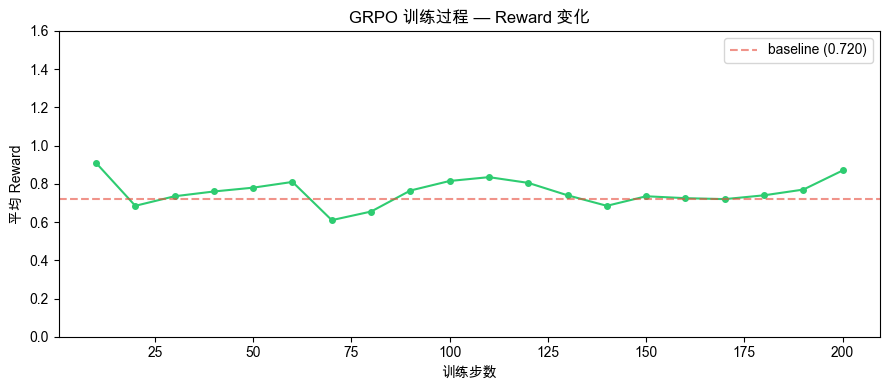

起始 reward: 0.910
最终 reward: 0.870
提升幅度:    -0.040


In [20]:
# 9-1 Reward 曲线可视化
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'

log_history = trainer.state.log_history

steps, rewards = [], []
for entry in log_history:
    # TRL 0.29 key 是 rewards/reward_fn/mean，兼容旧版
    reward_val = (entry.get("rewards/reward_fn/mean")
                  or entry.get("rewards/mean")
                  or entry.get("reward"))
    if reward_val is not None and "step" in entry:
        steps.append(entry["step"])
        rewards.append(reward_val)

if steps:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(steps, rewards, marker="o", markersize=4, linewidth=1.5, color="#2ecc71")
    ax.axhline(y=avg_b, color="#e74c3c", linestyle="--", alpha=0.6, label=f"baseline ({avg_b:.3f})")
    ax.set_xlabel("训练步数")
    ax.set_ylabel("平均 Reward")
    ax.set_title("GRPO 训练过程 — Reward 变化")
    ax.legend()
    ax.set_ylim(0, 1.6)
    plt.tight_layout()
    plt.show()
    print(f"起始 reward: {rewards[0]:.3f}")
    print(f"最终 reward: {rewards[-1]:.3f}")
    print(f"提升幅度:    {rewards[-1] - rewards[0]:+.3f}")
else:
    print("日志中未找到 reward 数据，log_history 样本：")
    print(log_history[:2])

## 10. 保存模型

In [ ]:
# 10-1 保存模型
SAVE_PATH = "./checkpoints/grpo_qwen35_gsm8k_final"
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"模型已保存到 {SAVE_PATH}")

## 11. 小结

| 阶段 | 目标 | 状态 |
|---|---|---|
| 05 baseline | 0.8B 未训练格式正确率 | 单次采样偏高，探测实验 63% 更可信 |
| 05 训练后 | 格式正确率提升情况 | 模型输出崩溃，见踩坑记录 |

---

## 实验选型决策记录

### 第一步：为什么放弃 tool use

03/04 实验验证了 Qwen3.5-2B 对原生 function calling 的支持：
- 简单题（3+5）→ 直接答，不调工具 ✓
- 大数乘法（1847×293）→ 主动调 calculator，格式完全正确 ✓

**结论**：模型在 SFT 阶段已经学会了工具调用决策，没有 RL 的施力点。
换任务（工具选择、多步工具调用）大概率同样问题——Qwen 系列 SFT 太强。

### 第二步：为什么换 0.8B

RL 能起作用的前提：**模型当前有缺陷，且缺陷不是完全随机的**（偶尔对才有梯度信号）。

Qwen3.5-2B 对大多数任务能力太强，找不到合适的任务难度区间。
0.8B 参数量不到 2B 的一半，能力明显更弱，更容易找到"偶尔对、不稳定"的任务。

### 第三步：为什么做格式训练而不是答案正确率

探测实验（10题×6次）结果：
- **格式正确率：63%**（JSON 可解析）
- **答案正确率：23%**

两种训练方向的分析：

| 方向 | 可行性 | 原因 |
|---|---|---|
| 提升答案正确率 | ✗ 部分可行 | 难题（6题）6次全错，组内 reward 全0，GRPO 无梯度信号；只有容易题（4题）有信号 |
| 提升格式正确率 | ✓ 可行 | 63% 意味着所有题组内都有格式对/错的对比，梯度信号稳定 |

**GRPO 的边界**：能强化"模型偶尔能做对但不稳定"的行为；不能赋予模型本身不具备的推理能力。

### 最终方案

- 模型：Qwen3.5-0.8B
- 任务：GSM8K 数学题，要求输出严格 JSON `{"steps":[...], "answer": 数字}`
- Reward：只评估格式（JSON可解析+0.5，steps是list+0.3，answer是数字+0.2），不评估答案
- 预期：格式正确率从 63% 显著提升，答案正确率基本不变（验证 GRPO 边界）

---

## 训练结果

### reward 曲线

200步训练，reward_mean 在 0.65-0.91 之间抖动，无明显单调上升趋势：

```
step  10：0.91   step  60：0.81   step 110：0.84
step  20：0.69   step  70：0.61   step 140：0.69
step  30：0.74   step  80：0.66   step 170：0.72
step  40：0.76   step  90：0.77   step 200：0.87
step  50：0.78   step 100：0.82
```

### 训练后评估

模型输出完全崩溃——所有题目输出乱码（HTML 标签、`#include`、代码片段混杂），reward 全为 0。

---

## 踩坑记录

### 1. baseline 单次采样不可信

第 6-1 cell 每题只跑 1 次，恰好采到好结果，显示 reward 很高。
实际探测实验每题跑 6 次，格式正确率只有 63%。
**教训**：评估必须多次采样取平均，单次结果运气成分大。

### 2. 训练后模型输出崩溃

200 步训练后模型输出变成乱码，语言能力完全丧失。
**现象**：输出混杂 HTML、C++ 代码、随机数字，reward 全 0。
**原因**：KL 散度惩罚不足，0.8B 小模型被 200 步 RL 拉偏太远，权重偏离原始分布导致退化。
注意：不是 reward hacking——reward 函数要求完整 `{}` 才得分，乱码无法触发。
**修复方向**：增大 `kl_coeff`（加强 KL 约束），或减少训练步数，防止模型偏离太远。